# Panel Gauss–Legendre n-modes — where the nodes go

`INSPECTRE_INTEG_PANEL_GL` computes the n-mode amplitudes

$$A_n = \frac{1}{T_r}\int_0^{T_r} e^{i(m\Omega_\phi + n\Omega_r)t}\, g_m(t)\,dt$$

by building **one node set per field point** and reusing it for every $n$:

1. **Breakpoints** — the Mino times $\lambda_c$ of closest approach are known in
   closed form ($\psi_c = \arccos((p/r_f-1)/e)$): two per period inside the
   libration range, one (a turning point) outside.
2. **Geometric stack** — toward each breakpoint, panel widths halve down to the
   peak's own $\lambda$-scale (max `maxLevels` halvings), so the near-singular
   peak is resolved with $O(\log)$ panels.
3. **Oscillation subdivision** — every panel is split until
   $\omega_{\max}\,\Delta t \lesssim$ `order`, with
   $\omega_{\max} = |m|\Omega_\phi + n_{\max}\Omega_r$, so a fixed-order GL rule
   resolves the carrier up to the requested $n_{\max}$.
4. **GL nodes** — an `order`-point Gauss–Legendre rule per panel; the source is
   evaluated once per node; each $A_n$ is then a weighted phase sum.

This notebook *shows* that construction: panel placements and GL node positions
on the time-series data, and how they respond to the field point and to
$(m, n)$. All panel structure lives on the **Mino-time axis** $\lambda$ (where
the breakpoints are analytic), so every x-axis below is $\lambda/\Lambda_r$.

In [1]:
import sys, os
for rel in ('..', '../../effectivesource', '../../kerrgeodesic'):
    sys.path.insert(0, os.path.abspath(rel))
import numpy as np
import matplotlib.pyplot as plt
from inspectre.inspectre import Inspectre
import inspectre_c as c

# palette (validated): blue = data/nodes, green = orbit, yellow = breakpoints
BLUE, GREEN, YELLOW = '#2a78d6', '#008300', '#eda100'
INK, MUTE = '#222222', '#888888'
PANEL_A, PANEL_B = '#00000012', '#00000004'   # alternating panel shading
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.15,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})

a, p, e, M = 0.5, 10.0, 0.3, 2
insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e)
Vr = insp.mino_period_r
Tr = insp.t_from_lambda(Vr)
om_r, om_ph = insp.omega_r, insp.omega_phi
rmin, rmax = p/(1+e), p/(1-e)

r_near  = p/(1+0.5*e)              # inside libration range -> 2 breakpoints
th_near = np.pi/2 + 0.01           # slightly off-equator (finite peak)
r_out   = rmax + 2.0               # outside libration range -> 1 breakpoint
print(f'Tr={Tr:.2f}  Vr={Vr:.4f}  r_min={rmin:.3f}  r_max={rmax:.3f}')

Tr=313.40  Vr=2.3519  r_min=7.692  r_max=14.286


In [2]:
def arr(ptr, n):
    """numpy copy of a SWIG double* of length n."""
    A = c.doubleArray.frompointer(ptr)
    return np.array([A[i] for i in range(n)])


def build_nodes(m, nMax, r_f, th_f, order=16, max_levels=40):
    """Panel-GL node set -> dict of numpy arrays (+ live handle for integrate)."""
    xF = insp.es.make_coordinate(0.0, r_f, th_f, 0.0)
    s = c.panel_nodes_build(insp._ctx, m, xF, insp._orbpar, a, p, e,
                            insp.omega_phi, insp.omega_r,
                            order=order, maxLevels=max_levels, nMax=nMax)
    N = s.n
    return dict(N=N, order=order, Tr=s.Tr, Vr=s.Vr, nBreak=s.nBreak,
                nNonFinite=s.nNonFinite,
                lamBreak=arr(s.lamBreak, 2)[:s.nBreak],
                dlam=arr(s.dlam, 2)[:s.nBreak],
                lam=arr(s.lam, N), t=arr(s.t, N), J=arr(s.J, N),
                w=arr(s.w, N), raw=arr(s.raw, 12 * N).reshape(12, N),
                m=m, nMax=nMax, r_f=r_f, th_f=th_f, _s=s)


def panel_edges(R):
    """Reconstruct panel [a,b] from the GL node groups (order nodes/panel):
    mid/half-width follow from the outermost abscissae of the exact GL rule."""
    q = R['order']
    lam = R['lam'].reshape(-1, q)
    lo, hi = lam.min(axis=1), lam.max(axis=1)
    xi = np.polynomial.legendre.leggauss(q)[0]
    half = (hi - lo) / (xi.max() - xi.min())
    mid = 0.5 * (lo + hi)
    return mid - half, mid + half


def shade_panels(ax, R, xnorm=True):
    pa, pb = panel_edges(R)
    sc = 1.0 / R['Vr'] if xnorm else 1.0
    for i, (A_, B_) in enumerate(zip(pa, pb)):
        ax.axvspan(A_ * sc, B_ * sc, color=PANEL_A if i % 2 == 0 else PANEL_B,
                   lw=0, zorder=0)
    return len(pa)


def mark_breaks(ax, R, label_y=None):
    x0 = R['lamBreak'][0] / R['Vr']      # true unwrapped domain, not the
    x1 = x0 + 1.0                        # (slightly interior) node range
    for k, lb in enumerate(R['lamBreak']):
        for off in (0.0, R['Vr']):     # breakpoints repeat with the period
            x = (lb + off) / R['Vr']
            if x0 - 1e-9 <= x <= x1 + 1e-9:
                ax.axvline(x, color=YELLOW, lw=1.4, ls='--', zorder=3)
                if label_y is not None:
                    # keep edge labels inside the axes
                    ha = 'left' if x < x1 - 0.05 else 'right'
                    dx = 4 if ha == 'left' else -4
                    ax.annotate(f'$\\lambda_{{c{k+1}}}$', (x, label_y),
                                color=INK, fontsize=9, ha=ha, va='top',
                                xytext=(dx, 0), textcoords='offset points')


def dense_series(m, r_f, th_f, nlam=1200):
    """S_m and r_p on a uniform lambda grid over one period (reference curve)."""
    xF = insp.es.make_coordinate(0.0, r_f, th_f, 0.0)
    lam = np.linspace(0.0, Vr, nlam, endpoint=False)
    src = np.empty(nlam, complex)
    phis = np.empty(nlam, complex)
    t = np.empty(nlam)
    for i, l in enumerate(lam):
        P, dP, dd, S = c.eval_at_lambda(insp._ctx, m, xF, float(l),
                                        insp._orbpar, a, p, e)
        src[i] = complex(S[0], S[1])
        phis[i] = complex(P[0], P[1])
        t[i] = insp.t_from_lambda(float(l))
    r_p = np.array([insp.r_from_lambda(float(l)) for l in lam])
    return dict(lam=lam, t=t, src=src, phis=phis, r_p=r_p)


def unwrap_to(R, lam_d, y_d):
    """Tile a periodic dense series onto the node window [lam0, lam0+Vr]."""
    lam2 = np.concatenate([lam_d, lam_d + Vr])
    y2 = np.concatenate([y_d, y_d])
    msk = (lam2 >= R['lam'][0] - 1e-12) & (lam2 <= R['lam'][-1] + 1e-12)
    return lam2[msk], y2[msk]

## 1. Overview — panels and GL nodes on the source time series

Near-orbit interior point ($r_f$ inside the libration range, $\Delta\theta=0.01$):
the particle crosses $r_f$ twice per period, giving **two breakpoints**. Top:
the orbital radius against the field radius — the crossings define
$\lambda_{c1,2}$. Bottom: $|S_m|$ along the worldline with the panel placements
(alternating shading), the GL nodes (dots at their sampled values), and the
breakpoints (dashed). Panels shrink geometrically into each breakpoint and are
subdivided in the smooth interior only as far as the carrier for
$n_{\max}=32$ requires.

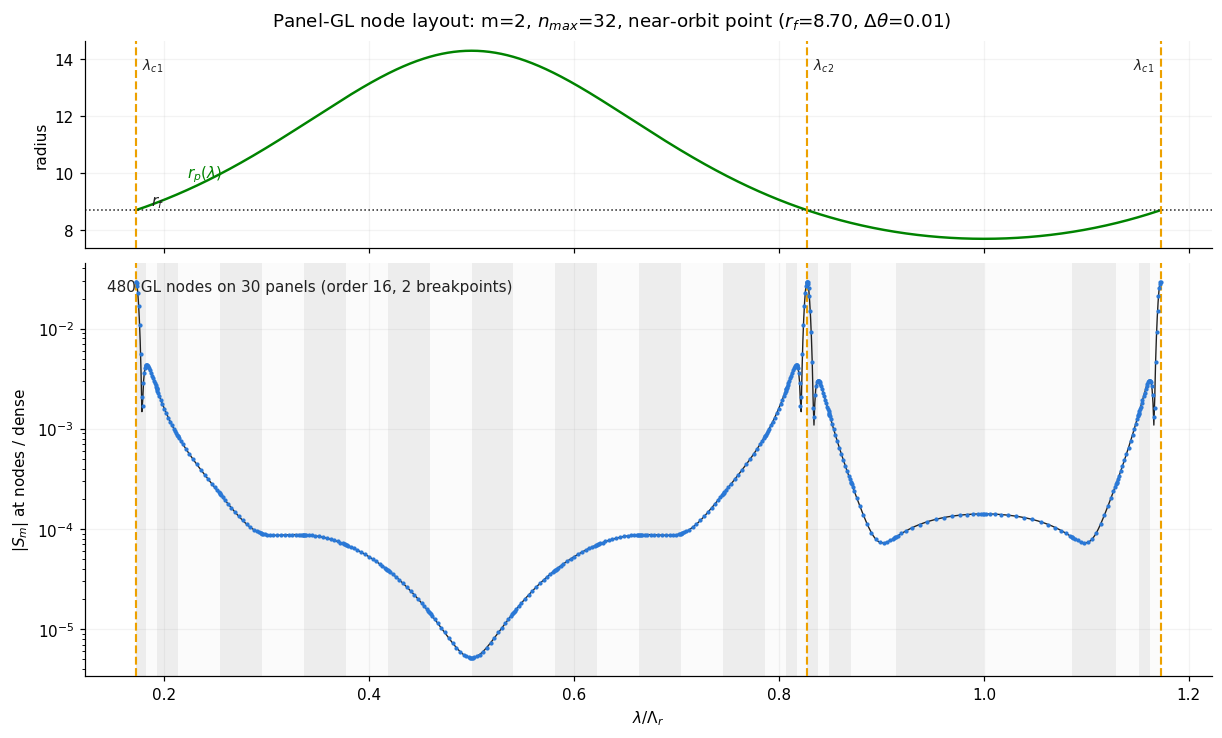

In [3]:
D_near = dense_series(M, r_near, th_near)
R1 = build_nodes(M, 32, r_near, th_near)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True,
                               height_ratios=[1, 2], constrained_layout=True)

lam_u, rp_u = unwrap_to(R1, D_near['lam'], D_near['r_p'])
srt = np.argsort(lam_u)
ax0.plot(lam_u[srt] / Vr, rp_u[srt], color=GREEN, lw=1.6)
ax0.axhline(R1['r_f'], color=INK, lw=1.0, ls=':')
ax0.annotate('$r_p(\\lambda)$', (lam_u[srt][60] / Vr, rp_u[srt][60]),
             color=GREEN, xytext=(0, 8), textcoords='offset points', fontsize=10)
ax0.annotate('$r_f$', (R1['lam'][0] / Vr + 0.015, R1['r_f']), color=INK,
             fontsize=10, va='bottom')
mark_breaks(ax0, R1, label_y=rmax - 0.2)
ax0.set_ylabel('radius')

nP = shade_panels(ax1, R1)
lam_s, src_s = unwrap_to(R1, D_near['lam'], np.abs(D_near['src']))
srt = np.argsort(lam_s)
ax1.plot(lam_s[srt] / Vr, src_s[srt], color=INK, lw=0.9)
node_amp = np.hypot(R1['raw'][10], R1['raw'][11])
ax1.plot(R1['lam'] / Vr, node_amp, '.', color=BLUE, ms=3.5, zorder=4)
mark_breaks(ax1, R1)
ax1.set_yscale('log')
ax1.set_xlabel('$\\lambda/\\Lambda_r$')
ax1.set_ylabel('$|S_m|$ at nodes / dense')
ax1.annotate(f"{R1['N']} GL nodes on {nP} panels "
             f"(order {R1['order']}, {R1['nBreak']} breakpoints)",
             (0.02, 0.96), xycoords='axes fraction', va='top', fontsize=10,
             color=INK)
fig.suptitle(f'Panel-GL node layout: m={M}, $n_{{max}}$=32, near-orbit point '
             f'($r_f$={r_near:.2f}, $\\Delta\\theta$=0.01)')
plt.show()

## 2. The geometric stack into a breakpoint

Distance of every node from its nearest breakpoint, log–log, with the
reconstructed panel edges (ticks). Panel widths halve toward the peak until
they reach the peak's own $\lambda$-scale `dlam` (left, off-orbit point:
the stack stops after $\sim\log_2(h/\delta\lambda)$ levels). At an **exact
crossing** (right, $\Delta\theta=0$, $r_f$ on the orbit) the distance is zero,
the stack runs to the full `maxLevels` = 40 halvings, and the innermost sliver
nodes that land in the divergent near zone are zeroed and counted
(`nNonFinite`). The puncture $|\Phi^S_m|$ stays finite (log peak), which is
what the plot shows.

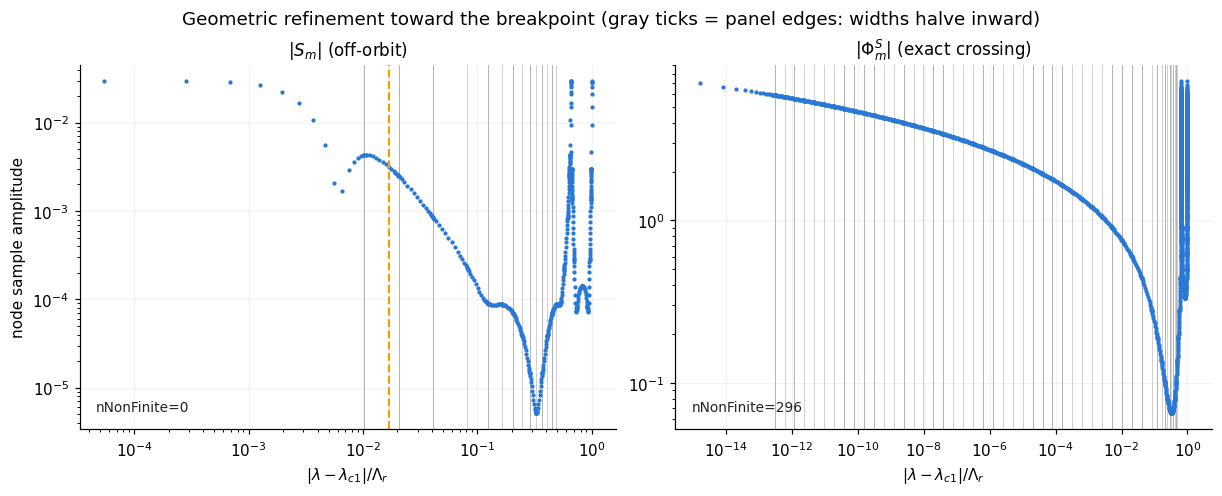

In [4]:
R_x = build_nodes(M, 32, r_near, np.pi / 2)     # exact crossing
D_x = dense_series(M, r_near, np.pi / 2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, R, comp, name in ((axes[0], R1, 10, '$|S_m|$ (off-orbit)'),
                          (axes[1], R_x, 0, '$|\\Phi^S_m|$ (exact crossing)')):
    lb = R['lamBreak'][0]
    d = np.abs(R['lam'] - lb)
    amp = np.hypot(R['raw'][comp], R['raw'][comp + 1])
    ok = (d > 0) & (amp > 0)
    ax.plot(d[ok] / Vr, amp[ok], '.', color=BLUE, ms=3.5)
    pa, pb = panel_edges(R)
    for edge in np.unique(np.concatenate([pa, pb])):
        de = abs(edge - lb) / Vr
        if 1e-14 < de < 0.5:
            ax.axvline(de, color=MUTE, lw=0.5, alpha=0.5, zorder=0)
    if R['dlam'][0] > 0:
        ax.axvline(R['dlam'][0] / Vr, color=YELLOW, lw=1.4, ls='--')
        ax.annotate('peak scale $\\delta\\lambda$',
                    (R['dlam'][0] / Vr, ax.get_ylim()[0]), color=INK,
                    fontsize=9, rotation=90, va='bottom', ha='right')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('$|\\lambda - \\lambda_{c1}|/\\Lambda_r$')
    ax.set_title(name, fontsize=11)
    ax.annotate(f"nNonFinite={R['nNonFinite']}", (0.03, 0.05),
                xycoords='axes fraction', fontsize=9, color=INK)
axes[0].set_ylabel('node sample amplitude')
fig.suptitle('Geometric refinement toward the breakpoint '
             '(gray ticks = panel edges: widths halve inward)')
plt.show()

## 3. Oscillation subdivision — how $n_{\max}$ (and $m$) grow the node set

The geometric stack is $n$-independent; what grows with $n_{\max}$ is the
uniform subdivision of the *smooth* panels, enforcing
$\omega_{\max}\Delta t \lesssim$ `order` with
$\omega_{\max}=|m|\Omega_\phi+n_{\max}\Omega_r$. Top: the carrier
$\mathrm{Re}\,e^{i(m\Omega_\phi+n\Omega_r)t(\lambda)}$ for the largest
requested mode — this is the oscillation the nodes must resolve (it is faster,
per unit $\lambda$, where the Jacobian $dt/d\lambda$ is large). Rows: node
positions for increasing $n_{\max}$ at $m=2$, plus one high-$m$ row — note the
wide mid-panel gaps filling in while the stacks at the breakpoints stay put.

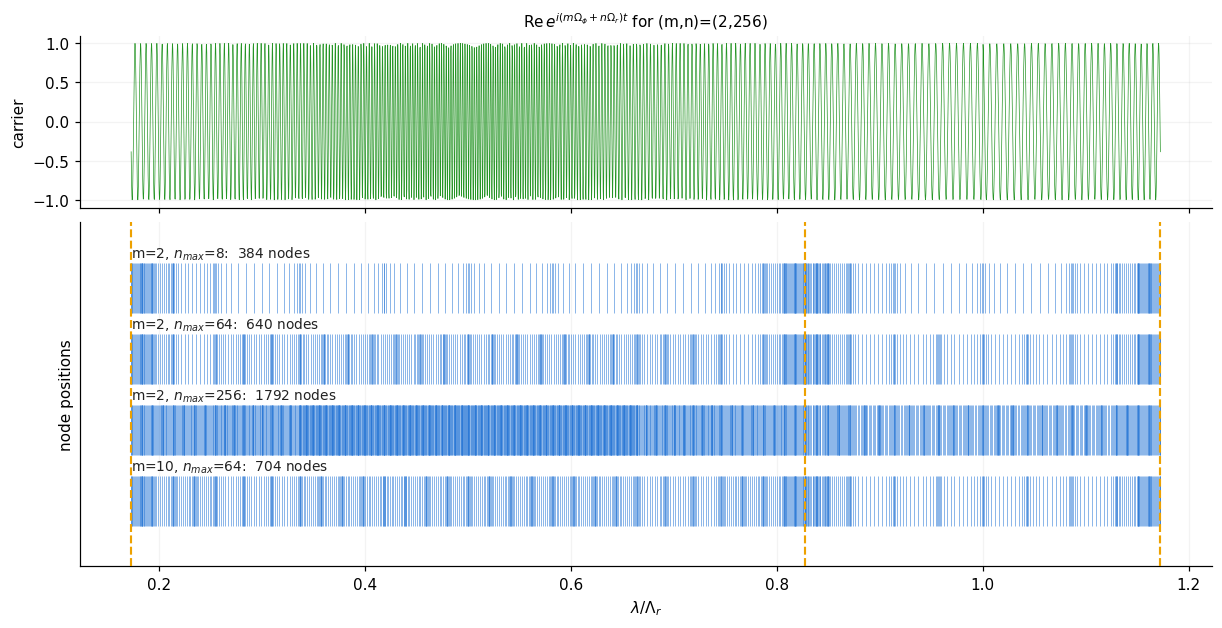

In [5]:
cases = [(2, 8), (2, 64), (2, 256), (10, 64)]
Rs = [build_nodes(m_, nmax_, r_near, th_near) for m_, nmax_ in cases]

fig, (axc, axr) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                               height_ratios=[1, 2], constrained_layout=True)
m_hi, n_hi = cases[2][0], cases[2][1]
lam_d = np.linspace(R1['lam'][0], R1['lam'][0] + Vr, 4000)
t_d = np.array([insp.t_from_lambda(float(l % Vr)) for l in lam_d])
axc.plot(lam_d / Vr, np.cos((m_hi * om_ph + n_hi * om_r) * t_d),
         color=GREEN, lw=0.45, alpha=0.85)
axc.set_ylabel('carrier')
axc.set_title(f'$\\mathrm{{Re}}\\,e^{{i(m\\Omega_\\phi+n\\Omega_r)t}}$ '
              f'for (m,n)=({m_hi},{n_hi})', fontsize=10)

for row, (R, (m_, nmax_)) in enumerate(zip(Rs, cases)):
    y = len(cases) - 1 - row
    axr.eventplot(R['lam'] / Vr, lineoffsets=y, linelengths=0.7,
                  colors=BLUE, lw=0.35)
    axr.annotate(f"m={m_}, $n_{{max}}$={nmax_}:  {R['N']} nodes",
                 (R['lam'][0] / Vr, y + 0.42), fontsize=9, color=INK)
mark_breaks(axr, Rs[0])
axr.set_yticks([])
axr.set_xlabel('$\\lambda/\\Lambda_r$')
axr.set_ylabel('node positions')
plt.show()

## 4. The integrand the nodes actually sum, for a few $(m,n)$

Each $A_n$ is the weighted phase sum
$\frac{1}{T_r}\sum_k w_k J_k\, e^{i\omega_{mn}t_k} g_m(t_k)$ over the *same*
stored samples. Below: $\mathrm{Re}\!\left[e^{i\omega_{mn}t}S_m\right]$ —
dense curve (ink) and its value at the GL nodes (blue dots) on the panel
layout, for four $(m,n)$ pairs. Low $n$: the peak at the breakpoints dominates
and the interior nodes are sparse. High $n$: the carrier oscillates through
the smooth region and the subdivided panels track every cycle. The title of
each panel shows the resulting amplitude $|A_n^{\rm src}|$.

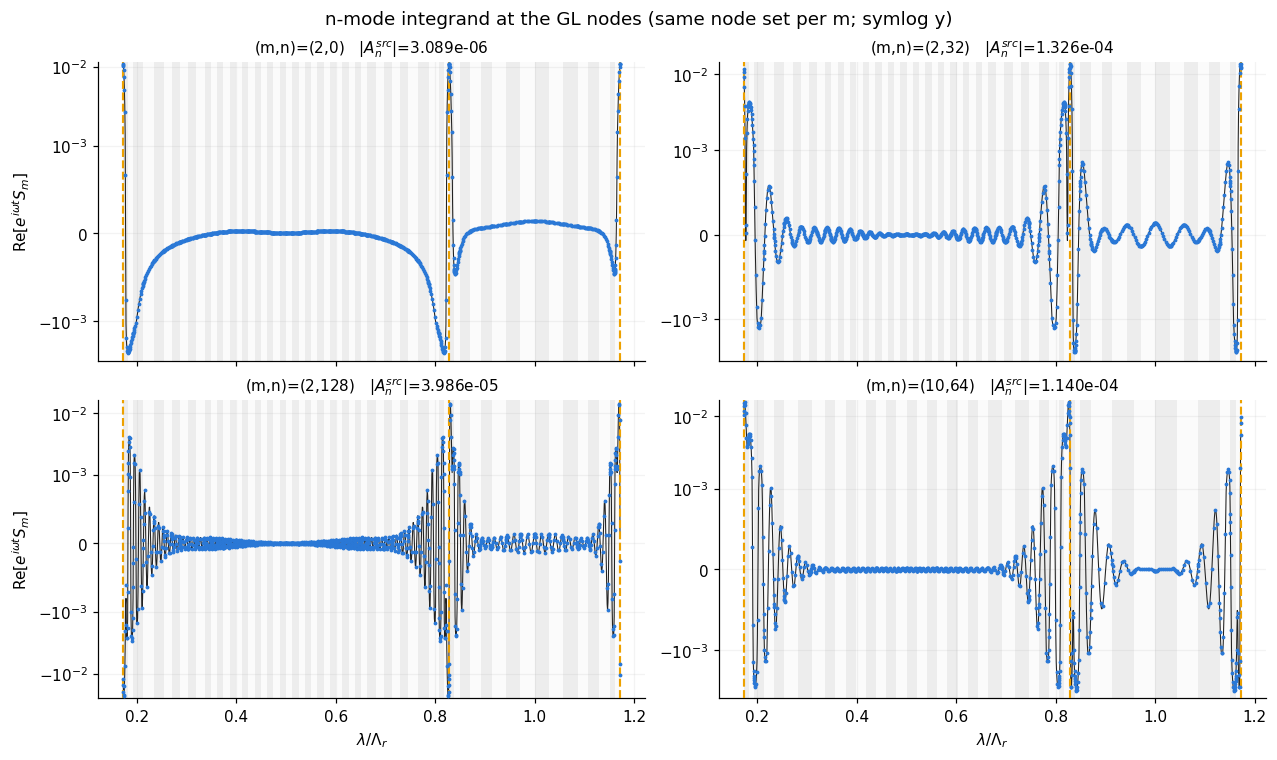

In [6]:
pairs = [(2, 0), (2, 32), (2, 128), (10, 64)]
Rm = {2: build_nodes(2, 128, r_near, th_near),
      10: build_nodes(10, 64, r_near, th_near)}
Dm = {2: D_near, 10: dense_series(10, r_near, th_near)}

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.8), sharex=True,
                         constrained_layout=True)
for ax, (m_, n_) in zip(axes.flat, pairs):
    R, D = Rm[m_], Dm[m_]
    shade_panels(ax, R)
    w_mn = m_ * om_ph + n_ * om_r
    lam_s, y_s = unwrap_to(R, D['lam'],
                           np.real(np.exp(1j * w_mn * D['t']) * D['src']))
    srt = np.argsort(lam_s)
    ax.plot(lam_s[srt] / Vr, y_s[srt], color=INK, lw=0.7)
    g_node = R['raw'][10] + 1j * R['raw'][11]
    y_node = np.real(np.exp(1j * w_mn * R['t']) * g_node)
    ax.plot(R['lam'] / Vr, y_node, '.', color=BLUE, ms=3.0, zorder=4)
    mark_breaks(ax, R)
    amp = c.panel_nodes_integrate(R['_s'], m_, n_, om_ph, om_r)
    An = complex(amp[2][0], amp[2][1])
    ax.set_yscale('symlog', linthresh=1e-3)
    ax.set_title(f'(m,n)=({m_},{n_})   $|A_n^{{src}}|$={abs(An):.3e}',
                 fontsize=10)
for ax in axes[1]:
    ax.set_xlabel('$\\lambda/\\Lambda_r$')
for ax in axes[:, 0]:
    ax.set_ylabel('$\\mathrm{Re}[e^{i\\omega t}S_m]$')
fig.suptitle('n-mode integrand at the GL nodes (same node set per m; '
             'symlog y)')
plt.show()

## 5. Outside the libration range — one breakpoint

For $r_f > r_{\max}$ there is no crossing; closest approach is apoapsis, so the
build clamps to a **single breakpoint** at $\lambda=\Lambda_r/2$ and stacks
panels toward it from both sides. The peak is analytic here (distance never
vanishes), so the stack is shallow and most nodes come from the oscillation
subdivision.

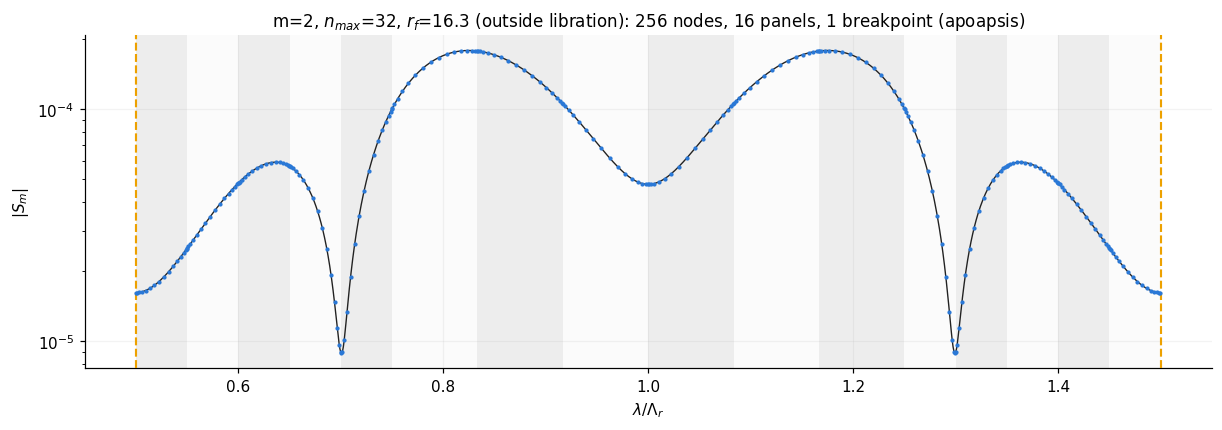

In [7]:
R_out = build_nodes(M, 32, r_out, np.pi / 2)
D_out = dense_series(M, r_out, np.pi / 2)

fig, ax = plt.subplots(figsize=(11, 3.8), constrained_layout=True)
nP = shade_panels(ax, R_out)
lam_s, src_s = unwrap_to(R_out, D_out['lam'], np.abs(D_out['src']))
srt = np.argsort(lam_s)
ax.plot(lam_s[srt] / Vr, src_s[srt], color=INK, lw=0.9)
ax.plot(R_out['lam'] / Vr, np.hypot(R_out['raw'][10], R_out['raw'][11]),
        '.', color=BLUE, ms=3.5, zorder=4)
mark_breaks(ax, R_out)
ax.set_yscale('log')
ax.set_xlabel('$\\lambda/\\Lambda_r$')
ax.set_ylabel('$|S_m|$')
ax.set_title(f'm={M}, $n_{{max}}$=32, $r_f$={r_out:.1f} (outside libration): '
             f"{R_out['N']} nodes, {nP} panels, "
             f"{R_out['nBreak']} breakpoint (apoapsis)", fontsize=11)
plt.show()

## Summary

* Breakpoints and the geometric stack are fixed by the **field point** alone;
  their node count is $O(\mathrm{order}\times\mathrm{levels})$.
* The oscillation subdivision is fixed by
  $\omega_{\max}=|m|\Omega_\phi+n_{\max}\Omega_r$ and grows the set roughly
  linearly in $n_{\max}$ (and mildly in $|m|$) — the wide smooth panels split,
  the stacks stay put.
* One build serves every $(m,n)$ with $m$ fixed and $|n|\le n_{\max}$: each
  amplitude is a weighted phase sum over the same stored samples
  (`panel_nodes_integrate`, no further source evaluations).
* At exact crossings the stack runs to `maxLevels` and the divergent innermost
  source samples are zeroed and counted (`nNonFinite`).